# Toy illustrations: bounded relative density ratios

This notebook combines the one-dimensional Gaussian and beta-mixture illustrations.
For densities $p$ and $q$, the target is
\[
r_0(x)=\frac{p(x)}{m(x)}=\frac{2p(x)}{p(x)+q(x)},\qquad m=(p+q)/2.
\]
The ordinary ratio $g_0=p/q$ can grow without bound; $r_0$ stays in $[0,2]$.
Values above one indicate relatively more probability density under $P$; values
below one indicate relatively more density under $Q$.

Run all cells from the repository root or this notebook's directory. If running
from another location, set `RDR_REPO_ROOT` to the checkout path. The notebook
uses CPU only, requires NumPy, SciPy, PyTorch and Matplotlib, and downloads no data.
It generates six new fits using independent data splits. These corrected illustrations
are not exact replays of the historical cached notebook outputs. They are descriptive
examples, not repeated benchmark
results or a selection of the best model. The separate model-selection workflow
compares loss functions, output activations and architectures.

In [1]:
import json
import os
import sys
from pathlib import Path

# Locate the checkout without changing the working directory.
repo_hint = os.environ.get("RDR_REPO_ROOT")
search_roots = [Path(repo_hint).expanduser()] if repo_hint else [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next((p.resolve() for p in search_roots
                  if (p / "utils" / "losses.py").is_file()
                  and (p / "experiments" / "simulations").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError("Run inside the checkout or set RDR_REPO_ROOT to its path.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import expit, logsumexp
from scipy.stats import beta, norm
import torch

from utils.networks import make_ratio_mlp
from utils.training import fit_ratio_mlp

CONFIG = {
    "seed": 123,
    "n_train": 2000,        # observations from EACH of P and Q
    "n_validation": 1000,  # independent data for stopping/checkpoint selection
    "n_evaluation": 5000,  # independent data for final metrics and score histograms
    "architecture": "baseline32",
    "output_alpha": 2.0,   # sigmoid slope; the midpoint mixture weight is always 1/2
    "loss": "hellinger",
    "max_epochs": 1000,
    "min_epochs": 300,
    "patience": 30,
}
# Optional figure/metric export; None leaves all results in the notebook session.
OUTPUT_DIR = None  # e.g. REPO_ROOT / "results" / "simulations" / "toy_illustrations"
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "savefig.bbox": "tight"})
print(json.dumps(CONFIG, indent=2))
print(f"NumPy {np.__version__}; SciPy {scipy.__version__}; PyTorch {torch.__version__}")

{
  "seed": 123,
  "n_train": 2000,
  "n_validation": 1000,
  "n_evaluation": 5000,
  "architecture": "baseline32",
  "output_alpha": 2.0,
  "loss": "hellinger",
  "max_epochs": 1000,
  "min_epochs": 300,
  "patience": 30
}
NumPy 1.26.4; SciPy 1.13.1; PyTorch 2.6.0+cu124


## Sampling and fitting protocol

Each case has six independent NumPy random streams: train/validation/evaluation
$\times$ $P/Q$. Network initialization has a seventh stream. Explicit stream keys
make results independent of the order in which cases are run. No evaluation
observations enter fitting or checkpoint selection.

The model is a three-hidden-layer, width-32 ReLU network with output
$2\,\operatorname{sigmoid}(2z)$. The shared trainer uses the midpoint Hellinger
objective and restores the best validation checkpoint. Training losses are
optimization criteria and are not reported as estimated divergences.

In [2]:
SPLIT_IDS = {"train": 0, "validation": 1, "evaluation": 2}

def case_rng(case_id, split_name, distribution_id):
    """Independent reproducible stream for one case, split and P/Q source."""
    return np.random.default_rng(np.random.SeedSequence(
        [CONFIG["seed"], case_id, SPLIT_IDS[split_name], distribution_id]))


def predict(model, x):
    model.eval()
    with torch.no_grad():
        values = model(torch.as_tensor(x, dtype=torch.float32).reshape(-1, 1))
    values = values.numpy().ravel()
    assert np.isfinite(values).all() and np.all((0 <= values) & (values <= 2))
    return values


def fit_case(case_id, name, sample_p, sample_q, true_ratio):
    """Fit on training data, select on validation data, then evaluate once."""
    samples = {}
    for split_name in SPLIT_IDS:
        n = CONFIG[f"n_{split_name}"]
        samples[split_name] = tuple(
            sampler(n, case_rng(case_id, split_name, distribution_id)).reshape(-1, 1)
            for distribution_id, sampler in enumerate((sample_p, sample_q)))
    seed = int(np.random.SeedSequence([CONFIG["seed"], case_id, 99])
               .generate_state(1)[0])
    model = make_ratio_mlp(1, architecture=CONFIG["architecture"],
                           output_alpha=CONFIG["output_alpha"], seed=seed)
    model, training_metadata, history = fit_ratio_mlp(
        model, *samples["train"], *samples["validation"], loss=CONFIG["loss"],
        max_epochs=CONFIG["max_epochs"], min_epochs=CONFIG["min_epochs"],
        patience=CONFIG["patience"])
    x_p, x_q = samples["evaluation"]
    r_p, r_q = predict(model, x_p), predict(model, x_q)
    truth_p, truth_q = true_ratio(x_p.ravel()), true_ratio(x_q.ravel())
    metrics = {
        "case": name,
        "evaluation_mse": float(0.5 * (np.mean((r_p-truth_p)**2)
                                      + np.mean((r_q-truth_q)**2))),
        "evaluation_brier": float(0.5 * (np.mean((r_p/2-1)**2)
                                        + np.mean((r_q/2)**2))),
        "epochs": len(history),
    }
    print(f"{name}: MSE={metrics['evaluation_mse']:.5f}, "
          f"Brier={metrics['evaluation_brier']:.5f}, epochs={metrics['epochs']}")
    return {"model": model, "metrics": metrics, "training_metadata": training_metadata,
            "evaluation_scores": (r_p, r_q), "initialization_seed": seed}

## Gaussian mean separation

For $P=N(\delta,1)$ and $Q=N(-\delta,1)$,
\[
\log g_0(x)=2\delta x,\qquad r_0(x)=2\operatorname{sigmoid}(2\delta x).
\]
The columns use $\delta=0,1,4$. Top: exact densities. Middle: the true RDR and
its neural estimate. Bottom: the **analytic ordinary ratio**, on a logarithmic
axis. We do not fit an unbounded ordinary ratio with a bounded-output network.
The RDR transition in low-density regions, especially the gap at $\delta=4$,
should not be read as evidence of high estimation precision there.

Gaussian delta=0: MSE=0.00015, Brier=0.24997, epochs=330
Gaussian delta=1: MSE=0.00609, Brier=0.11510, epochs=330
Gaussian delta=4: MSE=0.00019, Brier=0.00008, epochs=929


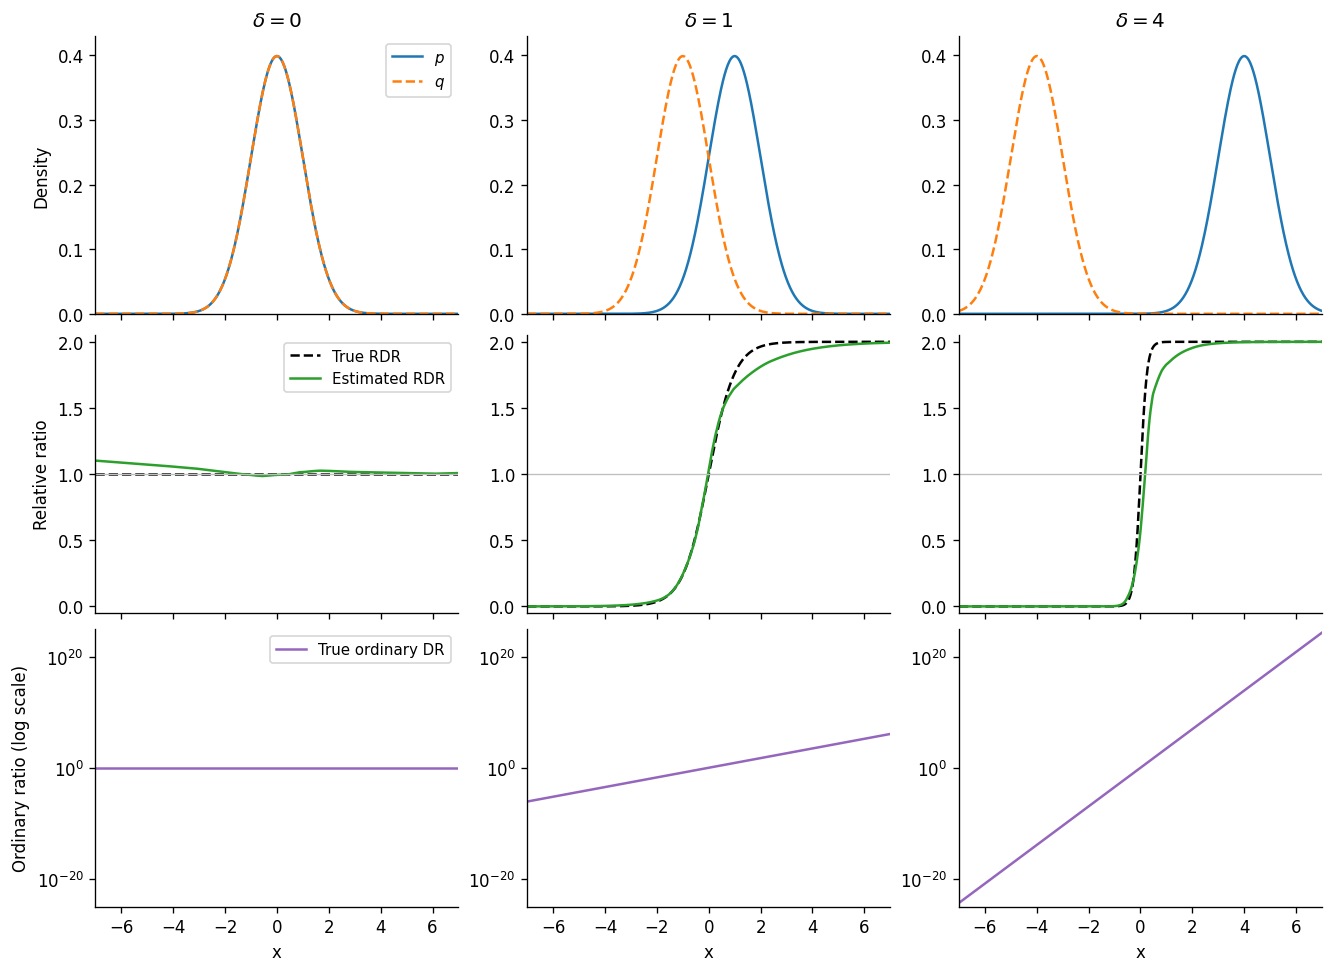

In [3]:
DELTAS = (0.0, 1.0, 4.0)
gaussian_results = []
for case_id, delta in enumerate(DELTAS):
    sample_p = lambda n, rng, d=delta: rng.normal(d, 1, n)
    sample_q = lambda n, rng, d=delta: rng.normal(-d, 1, n)
    true_ratio = lambda x, d=delta: 2 * expit(2 * d * np.asarray(x))
    gaussian_results.append(fit_case(case_id, f"Gaussian delta={delta:g}",
                                     sample_p, sample_q, true_ratio))

x_gaussian = np.linspace(-7, 7, 700)
gaussian_figure, axes = plt.subplots(3, 3, figsize=(11, 8), sharex=True,
                                     constrained_layout=True)
for column, (delta, result) in enumerate(zip(DELTAS, gaussian_results)):
    axes[0, column].plot(x_gaussian, norm.pdf(x_gaussian, delta), label="$p$")
    axes[0, column].plot(x_gaussian, norm.pdf(x_gaussian, -delta), label="$q$", ls="--")
    axes[0, column].set_title(rf"$\delta={delta:g}$")
    axes[0, column].set_ylim(0, 0.43)
    axes[1, column].plot(x_gaussian, 2*expit(2*delta*x_gaussian),
                         label="True RDR", color="black", ls="--")
    axes[1, column].plot(x_gaussian, predict(result["model"], x_gaussian),
                         label="Estimated RDR", color="tab:green")
    axes[1, column].axhline(1, color="0.75", lw=0.8)
    axes[1, column].set_ylim(-0.05, 2.05)
    axes[2, column].semilogy(x_gaussian, np.exp(2*delta*x_gaussian),
                             color="tab:purple", label="True ordinary DR")
    axes[2, column].set_ylim(1e-25, 1e25)
    axes[2, column].set_yticks([1e-20, 1, 1e20])
    axes[2, column].set_xlabel("x")
    for row in range(3):
        axes[row, column].set_xlim(-7, 7)
axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Relative ratio")
axes[2, 0].set_ylabel("Ordinary ratio (log scale)")
for row in range(3):
    axes[row, 0].legend(fontsize=9)
plt.show()

## Beta mixtures: missing and additional probability mass

The three pairs preserve the original beta-mixture configurations. Write
$\operatorname{Beta}(a,b)$ for a beta density:

| Case | $P$ | $Q$ |
|---|---|---|
| A | $\operatorname{Beta}(30,10)$ | $\tfrac13[\operatorname{Beta}(5,15)+\operatorname{Beta}(15,5)+\operatorname{Beta}(1,1)]$ |
| B | Case A's $Q$ | Case A's $P$ |
| C | $0.55\operatorname{Beta}(3,14)+0.15\operatorname{Beta}(3,5)+0.30\operatorname{Beta}(30,15)$ | $0.40\operatorname{Beta}(11,9)+0.15\operatorname{Beta}(15,5)+0.45\operatorname{Beta}(20,3)$ |

If $P$ represents a reference distribution and $Q$ a generated distribution,
regions with $r_0>1$ suggest underrepresentation by $Q$ and regions with $r_0<1$
suggest excess mass under $Q$. These figures illustrate that interpretation;
they are not numerical precision/recall estimates.

Density ratios are evaluated via log densities. The plotting grid excludes
0 and 1, where both densities can vanish. Score histograms use **independent
evaluation observations**, with identical bins for $P$ and $Q$.

Beta A: broader Q: MSE=0.00199, Brier=0.14291, epochs=988
Beta B: broader P: MSE=0.01471, Brier=0.15054, epochs=429
Beta C: shifted mixture mass: MSE=0.00629, Brier=0.11894, epochs=895


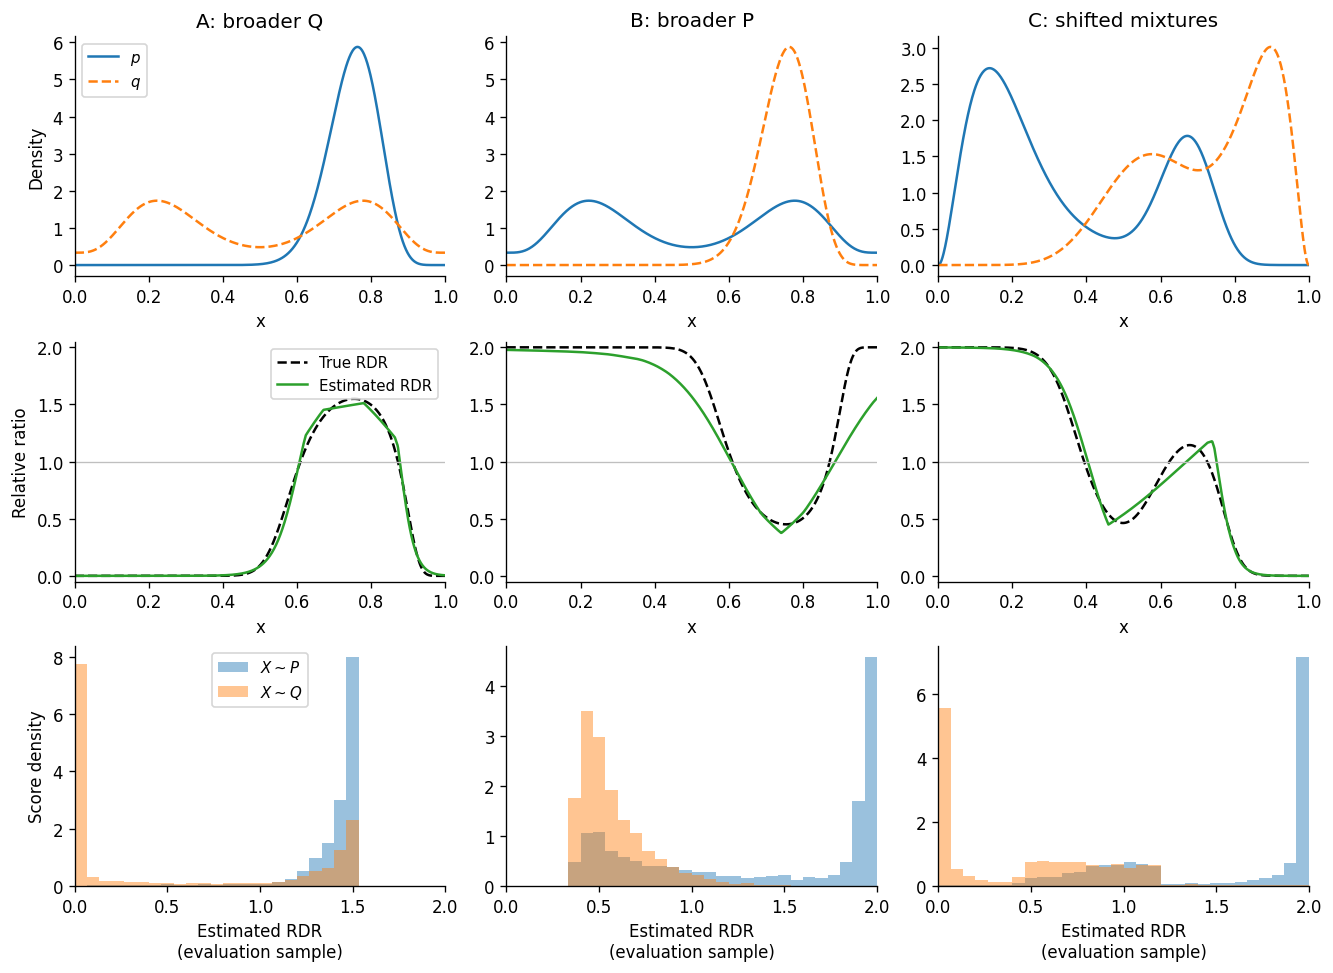

In [4]:
BETA_CASES = [
    {"name": "Beta A: broader Q",
     "p": ([1.0], [30], [10]),
     "q": ([1/3, 1/3, 1/3], [5, 15, 1], [15, 5, 1])},
    {"name": "Beta B: broader P",
     "p": ([1/3, 1/3, 1/3], [5, 15, 1], [15, 5, 1]),
     "q": ([1.0], [30], [10])},
    {"name": "Beta C: shifted mixture mass",
     "p": ([0.55, 0.15, 0.30], [3, 3, 30], [14, 5, 15]),
     "q": ([0.40, 0.15, 0.45], [11, 15, 20], [9, 5, 3])},
]

def sample_beta_mixture(n, parameters, rng):
    weights, a, b = (np.asarray(part) for part in parameters)
    components = rng.choice(len(weights), size=n, p=weights)
    return rng.beta(a[components], b[components])


def beta_log_density(x, parameters):
    weights, a, b = (np.asarray(part) for part in parameters)
    x = np.asarray(x).reshape(-1, 1)
    return logsumexp(np.log(weights) + beta.logpdf(x, a, b), axis=1)


def beta_truth(x, p, q):
    return 2 * expit(beta_log_density(x, p) - beta_log_density(x, q))


beta_results = []
for case_id, case in enumerate(BETA_CASES, start=3):
    sample_p = lambda n, rng, p=case["p"]: sample_beta_mixture(n, p, rng)
    sample_q = lambda n, rng, q=case["q"]: sample_beta_mixture(n, q, rng)
    true_ratio = lambda x, p=case["p"], q=case["q"]: beta_truth(x, p, q)
    beta_results.append(fit_case(case_id, case["name"], sample_p, sample_q, true_ratio))

x_beta = np.linspace(1e-4, 1-1e-4, 700)
beta_figure, axes = plt.subplots(3, 3, figsize=(11, 8), constrained_layout=True)
score_bins = np.linspace(0, 2, 31)
for column, (case, result) in enumerate(zip(BETA_CASES, beta_results)):
    axes[0, column].plot(x_beta, np.exp(beta_log_density(x_beta, case["p"])), label="$p$")
    axes[0, column].plot(x_beta, np.exp(beta_log_density(x_beta, case["q"])), label="$q$", ls="--")
    axes[0, column].set_title(("A: broader Q", "B: broader P", "C: shifted mixtures")[column])
    axes[1, column].plot(x_beta, beta_truth(x_beta, case["p"], case["q"]),
                         label="True RDR", color="black", ls="--")
    axes[1, column].plot(x_beta, predict(result["model"], x_beta),
                         label="Estimated RDR", color="tab:green")
    axes[1, column].axhline(1, color="0.75", lw=0.8)
    axes[1, column].set_ylim(-0.05, 2.05)
    for row in (0, 1):
        axes[row, column].set_xlim(0, 1)
        axes[row, column].set_xlabel("x")
    r_p, r_q = result["evaluation_scores"]
    axes[2, column].hist(r_p, bins=score_bins, density=True, alpha=0.45, label=r"$X\sim P$")
    axes[2, column].hist(r_q, bins=score_bins, density=True, alpha=0.45, label=r"$X\sim Q$")
    axes[2, column].set_xlim(0, 2)
    axes[2, column].set_xlabel("Estimated RDR\n(evaluation sample)")
axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Relative ratio")
axes[2, 0].set_ylabel("Score density")
for row in range(3):
    axes[row, 0].legend(fontsize=9)
plt.show()

## Evaluation summary and optional export

MSE averages $(\hat r-r_0)^2$ over an independent, equally weighted $P/Q$
evaluation sample. Balanced Brier uses labels one for $P$, zero for $Q$, and
prediction $\hat r/2$. Both are descriptive single-fit quantities; no uncertainty
interval or ranking across methods is inferred from this notebook.

Set `OUTPUT_DIR` in the configuration cell to save two PDF/PNG figures and a JSON
file containing settings, seeds, package versions and evaluation metrics.
The displayed outputs are freshly regenerated using these settings. Rerunning all
cells regenerates every fit, evaluation result and figure.

In [5]:
all_results = gaussian_results + beta_results
metrics = [result["metrics"] for result in all_results]
print(f"{'Case':<34} {'MSE':>10} {'Brier':>10} {'Epochs':>8}")
for row in metrics:
    print(f"{row['case']:<34} {row['evaluation_mse']:>10.5f} "
          f"{row['evaluation_brier']:>10.5f} {row['epochs']:>8}")

if OUTPUT_DIR is not None:
    output_dir = Path(OUTPUT_DIR).expanduser().resolve()
    output_dir.mkdir(parents=True, exist_ok=True)
    for name, figure in (("gaussian_toy", gaussian_figure), ("beta_toy", beta_figure)):
        figure.savefig(output_dir / f"{name}.pdf")
        figure.savefig(output_dir / f"{name}.png", dpi=180)
    provenance = {
        "configuration": CONFIG,
        "split_stream_keys": "[seed, case_id, split_id, distribution_id]",
        "split_ids": SPLIT_IDS,
        "distribution_ids": {"P": 0, "Q": 1},
        "case_order": [row["case"] for row in metrics],
        "initialization_seeds": [r["initialization_seed"] for r in all_results],
        "versions": {"numpy": np.__version__, "scipy": scipy.__version__,
                     "torch": torch.__version__},
        "metrics": metrics,
        "training_metadata": [r["training_metadata"] for r in all_results],
    }
    (output_dir / "toy_results.json").write_text(json.dumps(provenance, indent=2) + "\n")
    print(f"Saved figures and metrics to {output_dir}")

Case                                      MSE      Brier   Epochs
Gaussian delta=0                      0.00015    0.24997      330
Gaussian delta=1                      0.00609    0.11510      330
Gaussian delta=4                      0.00019    0.00008      929
Beta A: broader Q                     0.00199    0.14291      988
Beta B: broader P                     0.01471    0.15054      429
Beta C: shifted mixture mass          0.00629    0.11894      895
